In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re

# Load your data
df = pd.read_csv('C:/Users/DELL/Downloads/Legal Case/processed_data/clean_legal_cases.csv')
df.head()

,Case_ID,Case_Name,Source_Folder,Year,Court,Case_Text,Case_Text_Full_Length,Verdict,Case_Type,Sub_Type,Num_Citations,Legal_Citations,Decision_Date,First_Page,Last_Page
0,16,0016-01,file1,1818,Supreme Court of Indiana,Cole v. Driskell. Debt will He on the judgment...,8971,Per Curiam: Judgment AFFIRMED,Civil Procedure,Demurrer,17,1 Blackf. 16; 1 Caines' Rep. 460; 1 Doug. 4; 1...,1818-05-16,16,18
1,262,0262-01,file1,1823,Supreme Court of Indiana,"Findley v. Cooley. A vendee of real estate, ca...",9242,Per Curiam: Judgment AFFIRMED,Contract Law - Debt,Promissory Note,8,"1 Blackf. 262; 1 Cranch, 316; 2 Wheat. 13; 3 C...",1823-11-05,262,266
2,176,0176-01,file1,1822,Supreme Court of Indiana,"Savage and Others, Administrators of Prentiss,...",1501,Per Curiam: Judgment REVERSED,Civil Procedure,Demurrer,3,1 Blackf. 176; 1 Doug. 4; 16 Mass. 71,1822-05-09,176,177
3,217,0217-01,file1,1822,Supreme Court of Indiana,"Duerson and Others v. Bellows, Administrator. ...",3521,Per Curiam: Judgment REVERSED,Contract Law - Debt,Bond,4,1 Blackf. 217; 1 Gall. 388; 5 Co. R. 22; State...,1822-11-09,217,218
4,258,0258-01,file1,1823,Supreme Court of Indiana,Wilcox v. Webb and Wife. In slander for words ...,2771,Per Curiam: Judgment AFFIRMED,Torts - Defamation,Slander,9,1 Blackf. 258; 1 Gall. 26; 1 Gall. 261; 1 Gall...,1823-05-21,258,259


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4026 entries, 0 to 4025
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Case_ID                4026 non-null   int64 
 1   Case_Name              4026 non-null   object
 2   Source_Folder          4026 non-null   object
 3   Year                   4026 non-null   int64 
 4   Court                  4026 non-null   object
 5   Case_Text              4026 non-null   object
 6   Case_Text_Full_Length  4026 non-null   int64 
 7   Verdict                4026 non-null   object
 8   Case_Type              4026 non-null   object
 9   Sub_Type               4026 non-null   object
 10  Num_Citations          4026 non-null   int64 
 11  Legal_Citations        4026 non-null   object
 12  Decision_Date          4026 non-null   object
 13  First_Page             4026 non-null   int64 
 14  Last_Page              4026 non-null   object
dtypes: int64(5), object(1

In [4]:
# ============================================================
# CASE TYPE ANALYSIS (STATISTICS + UNIQUE VALUES)
# ============================================================

import pandas as pd

print("\n" + "=" * 70)
print("CASE TYPE ANALYSIS")
print("=" * 70)

# 1. Unique values
unique_case_types = df['Case_Type'].unique()
print(f"\nTotal Unique Case Types: {len(unique_case_types)}")
print("\nSample Case Types:")
print(unique_case_types[:20])  # show first 20 if many

# 2. Frequency distribution
case_type_dist = df['Case_Type'].value_counts(dropna=False)

# 3. Convert to structured table
case_type_table = pd.DataFrame({
    'Case_Type': case_type_dist.index,
    'Count': case_type_dist.values
})

case_type_table['Percentage'] = (
    case_type_table['Count'] / len(df) * 100
)

# 4. Print table
print("\nTop Case Types (Full Distribution):")
print(case_type_table)

# 5. Terminal-style visualization
print("\nDistribution Chart:")
for _, row in case_type_table.iterrows():
    bar = "█" * int(row['Percentage'] / 2)
    print(f"{row['Case_Type']:<35} {row['Count']:>6} ({row['Percentage']:5.1f}%) {bar}")

# 6. Basic stats
print("\nSummary Stats:")
print(f"Total rows: {len(df)}")
print(f"Unique case types: {df['Case_Type'].nunique()}")
print(f"Most common: {case_type_dist.idxmax()} ({case_type_dist.max()} cases)")
print(f"Least common: {case_type_dist.idxmin()} ({case_type_dist.min()} cases)")


CASE TYPE ANALYSIS

Total Unique Case Types: 7

Sample Case Types:
['Civil Procedure' 'Contract Law - Debt' 'Torts - Defamation'
 'Criminal Law' 'Property Law - Ejectment' 'Property Law - Execution Sale'
 'Torts']

Top Case Types (Full Distribution):
                       Case_Type  Count  Percentage
0                Civil Procedure   1978   49.130651
1                   Criminal Law   1101   27.347243
2            Contract Law - Debt    413   10.258321
3       Property Law - Ejectment    290    7.203179
4             Torts - Defamation    155    3.849975
5  Property Law - Execution Sale     47    1.167412
6                          Torts     42    1.043219

Distribution Chart:
Civil Procedure                       1978 ( 49.1%) ████████████████████████
Criminal Law                          1101 ( 27.3%) █████████████
Contract Law - Debt                    413 ( 10.3%) █████
Property Law - Ejectment               290 (  7.2%) ███
Torts - Defamation                     155 (  3.8%) █



Generating Case Type Visualization...


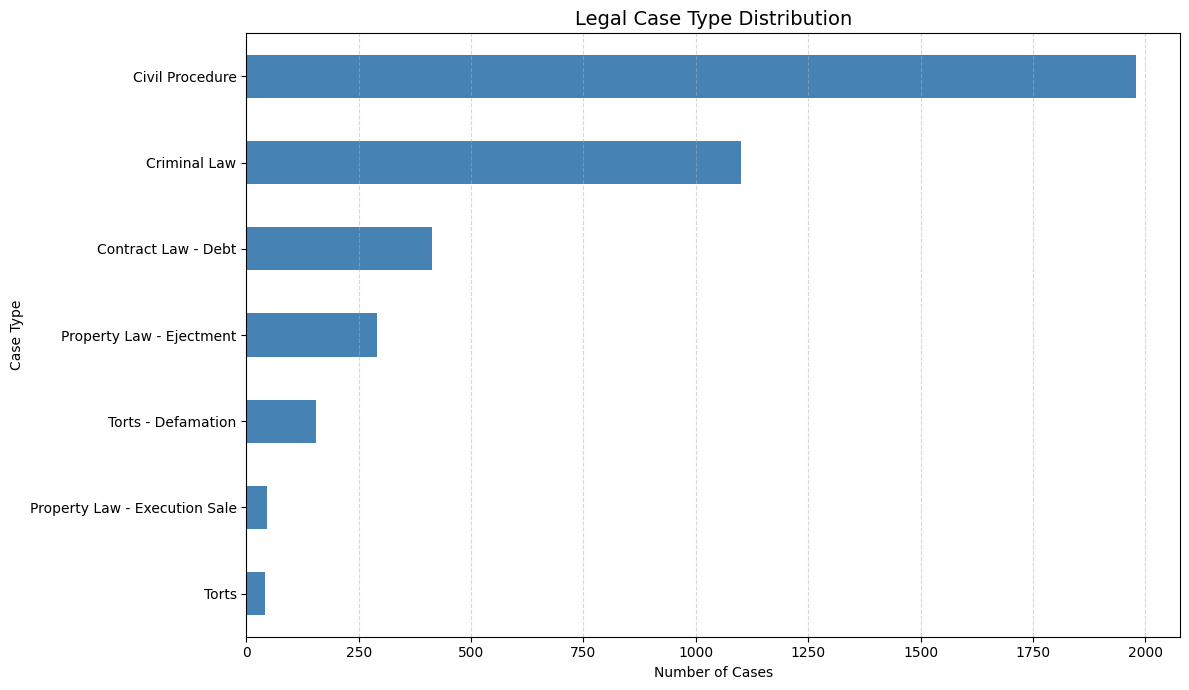

In [5]:
# ============================================================
# CASE TYPE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

print("\nGenerating Case Type Visualization...")

# Get distribution
case_type_dist = df['Case_Type'].value_counts()

# Sort for better visualization
case_type_dist_sorted = case_type_dist.sort_values()

# Plot
plt.figure(figsize=(12, 7))

case_type_dist_sorted.plot(
    kind='barh',
    color='steelblue'
)

plt.title('Legal Case Type Distribution', fontsize=14)
plt.xlabel('Number of Cases')
plt.ylabel('Case Type')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# show
plt.show()

In [6]:
# ============================================================
# 4. CLEAN CASE TEXT (LEGAL NLP PREPROCESSING)
# ============================================================

def clean_legal_text(text):
    text = str(text).lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = text.strip()
    return text

df['Case_Text'] = df['Case_Text'].apply(clean_legal_text)

In [7]:
# ============================================================
# 5. CASE TYPE MERGING
# ============================================================

case_type_mapping = {
    "Civil Procedure": "CIVIL",
    "Criminal Law": "CRIMINAL",
    "Contract Law - Debt": "CONTRACT",
    "Property Law - Ejectment": "PROPERTY",
    "Property Law - Execution Sale": "PROPERTY",
    "Torts - Defamation": "TORTS",
    "Torts": "TORTS"
}

# Create merged labels
df["Merged_Case_Type"] = df["Case_Type"].map(case_type_mapping)

# Check distribution
print("=" * 60)
print("MERGED CLASS DISTRIBUTION")
print("=" * 60)

print(df["Merged_Case_Type"].value_counts())

print("\nPercentage Distribution:\n")
print(df["Merged_Case_Type"].value_counts(normalize=True) * 100)

MERGED CLASS DISTRIBUTION
Merged_Case_Type
CIVIL       1978
CRIMINAL    1101
CONTRACT     413
PROPERTY     337
TORTS        197
Name: count, dtype: int64

Percentage Distribution:

Merged_Case_Type
CIVIL       49.130651
CRIMINAL    27.347243
CONTRACT    10.258321
PROPERTY     8.370591
TORTS        4.893194
Name: proportion, dtype: float64


In [8]:
# ============================================================
# 7. LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Convert text labels into numeric labels
df["Label"] = label_encoder.fit_transform(df["Merged_Case_Type"])

# Show mapping
print("=" * 60)
print("LABEL ENCODING MAPPING")
print("=" * 60)

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} --> {i}")

LABEL ENCODING MAPPING
CIVIL --> 0
CONTRACT --> 1
CRIMINAL --> 2
PROPERTY --> 3
TORTS --> 4


In [9]:
# ============================================================
# 8. FEATURE & TARGET SPLIT
# ============================================================

# Text feature
X_text = df["Case_Text"]

# Numeric feature
X_numeric = df[["Case_Text_Full_Length"]]

# Target
y = df["Label"]

print("=" * 60)
print("FEATURE & TARGET INFO")
print("=" * 60)

print("Text Samples:", len(X_text))
print("Numeric Shape:", X_numeric.shape)
print("Labels:", len(y))

FEATURE & TARGET INFO
Text Samples: 4026
Numeric Shape: (4026, 1)
Labels: 4026


In [10]:
# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

(
    X_text_train,
    X_text_test,
    X_num_train,
    X_num_test,
    y_train,
    y_test
) = train_test_split(
    X_text,
    X_numeric,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN TEST SPLIT COMPLETE")
print("=" * 60)

print("X_text_train:", X_text_train.shape)
print("X_text_test :", X_text_test.shape)
print("X_num_train :", X_num_train.shape)
print("X_num_test  :", X_num_test.shape)

TRAIN TEST SPLIT COMPLETE
X_text_train: (3220,)
X_text_test : (806,)
X_num_train : (3220, 1)
X_num_test  : (806, 1)


In [ ]:
# ============================================================
# 10. TF-IDF VECTORIZATION
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=30000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

# Fit and transform training text
X_train_tfidf = tfidf_vectorizer.fit_transform(X_text_train)

# Transform test text
X_test_tfidf = tfidf_vectorizer.transform(X_text_test)

print("=" * 60)
print("TF-IDF COMPLETE")
print("=" * 60)

print("Train Shape:", X_train_tfidf.shape)
print("Test Shape :", X_test_tfidf.shape)

In [ ]:
# ============================================================
# 11. SCALE NUMERIC FEATURES
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_train_scaled = scaler.fit_transform(X_num_train)

X_num_test_scaled = scaler.transform(X_num_test)

print("=" * 60)
print("NUMERIC FEATURE SCALING COMPLETE")
print("=" * 60)
print(X_num_train_scaled.shape)

In [ ]:
# ============================================================
# 12. COMBINE FEATURES
# ============================================================

from scipy.sparse import hstack

# Combine sparse TF-IDF with numeric features
X_train_combined = hstack([
    X_train_tfidf,
    X_num_train_scaled
])

X_test_combined = hstack([
    X_test_tfidf,
    X_num_test_scaled
])

print("=" * 60)
print("COMBINED FEATURE SHAPES")
print("=" * 60)

print("Train:", X_train_combined.shape)
print("Test :", X_test_combined.shape)